In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import keras as kf
from keras.utils import image_dataset_from_directory, to_categorical
from keras.layers import (Conv2D, BatchNormalization, Activation,
                           MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout)
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
import time
from sklearn.metrics import (confusion_matrix, classification_report,
                              precision_score, recall_score, f1_score,
                              roc_curve, auc)
from sklearn.utils.class_weight import compute_class_weight

In [2]:
input_shape=(224,224,1)
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 4
EPOCHS = 30
DATASET_PATH = "split_dataset_final" 
SEED=42
AUTOTUNE= tf.data.AUTOTUNE   
np.random.seed(SEED)
tf.random.set_seed(SEED)

train_data = image_dataset_from_directory(
    f"{DATASET_PATH}/train",           
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    color_mode="grayscale",
    shuffle=True
)

val_data = image_dataset_from_directory(
    f"{DATASET_PATH}/val",            
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    color_mode="grayscale",
    shuffle=False                     
)

test_data = image_dataset_from_directory(
    f"{DATASET_PATH}/test",            
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    color_mode="grayscale",
    shuffle=False                      
)

class_names = train_data.class_names
print("Classes:", class_names)   
NUM_CLASSES = len(class_names)
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
], name="augmentation")

normalization_layer = tf.keras.layers.Rescaling(1./255)
train_data = (train_data
              .map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)
              .cache()
              .prefetch(AUTOTUNE))

val_data = (val_data
            .map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)
            .cache()
            .prefetch(AUTOTUNE))

test_data = (test_data
             .map(lambda x, y: (normalization_layer(x), y),   
                  num_parallel_calls=AUTOTUNE)
             .cache()
             .prefetch(AUTOTUNE))
             
all_labels = []
for _, labels in train_data:
    all_labels.extend(np.argmax(labels.numpy(), axis=1))
all_labels = np.array(all_labels)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(all_labels),
    y=all_labels
)
class_weight = dict(enumerate(class_weights))
print("Class weights:", class_weight)

Found 8946 files belonging to 4 classes.
Found 1788 files belonging to 4 classes.
Found 1195 files belonging to 4 classes.
Classes: ['Cyst', 'Normal', 'Stone', 'Tumor']
Class weights: {0: 0.9080389768574909, 1: 0.5962410023993602, 2: 2.1926470588235296, 3: 1.3063668224299065}


Epoch 1/30
280/280 [==============================] - 71s 212ms/step - loss: 1.2235 - accuracy: 0.5182 - val_loss: 2.6011 - val_accuracy: 0.2752 - lr: 1.0000e-05
Epoch 2/30
280/280 [==============================] - 56s 201ms/step - loss: 0.8590 - accuracy: 0.6506 - val_loss: 2.7891 - val_accuracy: 0.1281 - lr: 1.0000e-05
Epoch 3/30
280/280 [==============================] - 56s 201ms/step - loss: 0.7157 - accuracy: 0.7245 - val_loss: 1.1065 - val_accuracy: 0.4183 - lr: 1.0000e-05
Epoch 4/30
280/280 [==============================] - 56s 202ms/step - loss: 0.6024 - accuracy: 0.7825 - val_loss: 0.6667 - val_accuracy: 0.7483 - lr: 1.0000e-05
Epoch 5/30
280/280 [==============================] - 57s 203ms/step - loss: 0.4970 - accuracy: 0.8371 - val_loss: 0.5968 - val_accuracy: 0.7724 - lr: 1.0000e-05
Epoch 6/30
280/280 [==============================] - 57s 202ms/step - loss: 0.4047 - accuracy: 0.8745 - val_loss: 0.4238 - val_accuracy: 0.8686 - lr: 1.0000e-05
Epoch 7/30
280/280 [========

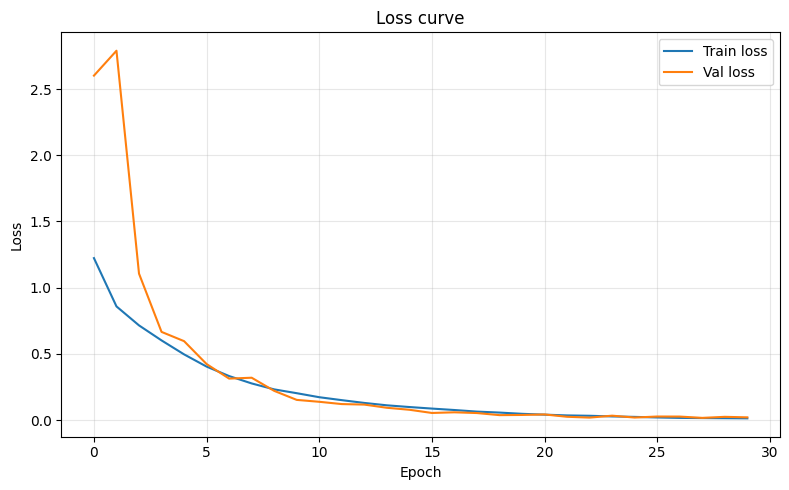

In [3]:
model=kf.Sequential([
    #block 1
    Conv2D(32,(3,3),padding="same",input_shape=input_shape),
    BatchNormalization(),
    Activation("relu"),
    Conv2D(32,(3,3),padding="same"),
    BatchNormalization(),
    Activation("relu"),
    MaxPooling2D(),

    #block 2
    Conv2D(64,(3,3),padding="same"),
    BatchNormalization(),
    Activation("relu"),
    Conv2D(64,(3,3),padding="same"),
    BatchNormalization(),
    Activation("relu"),
    MaxPooling2D(),

    #block 3
    Conv2D(128,(3,3),padding="same"),
    BatchNormalization(),
    Activation("relu"),
    Conv2D(128,(3,3),padding="same"),
    BatchNormalization(),
    Activation("relu"),
    MaxPooling2D(),

    Conv2D(256,(3,3),padding="same"),
    BatchNormalization(),
    Activation("relu"),
    Conv2D(256,(3,3),padding="same"),
    BatchNormalization(),
    Activation("relu"),
    MaxPooling2D(),

    GlobalAveragePooling2D(),
    Dense(256,activation="relu"),
    Dropout(0.3),
    Dense(NUM_CLASSES,activation="softmax")
])
model.compile(
    optimizer=kf.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)
]

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weight
)

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"],     label="Train loss")
plt.plot(history.history["val_loss"], label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



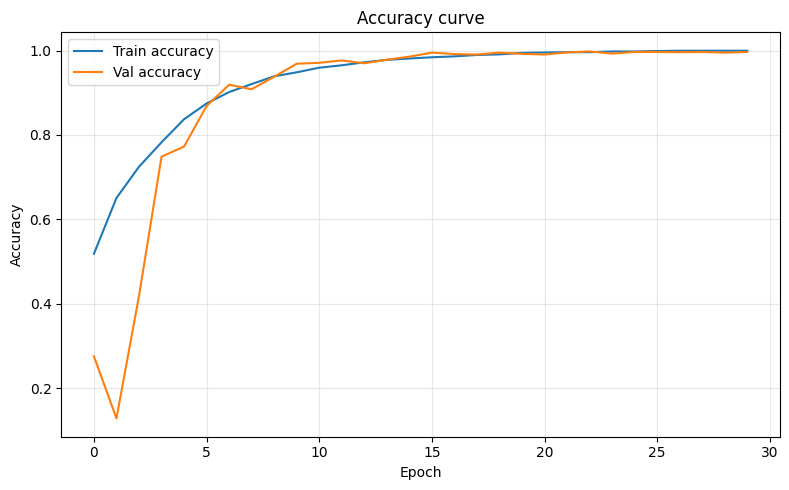

Inference time: 5.53s


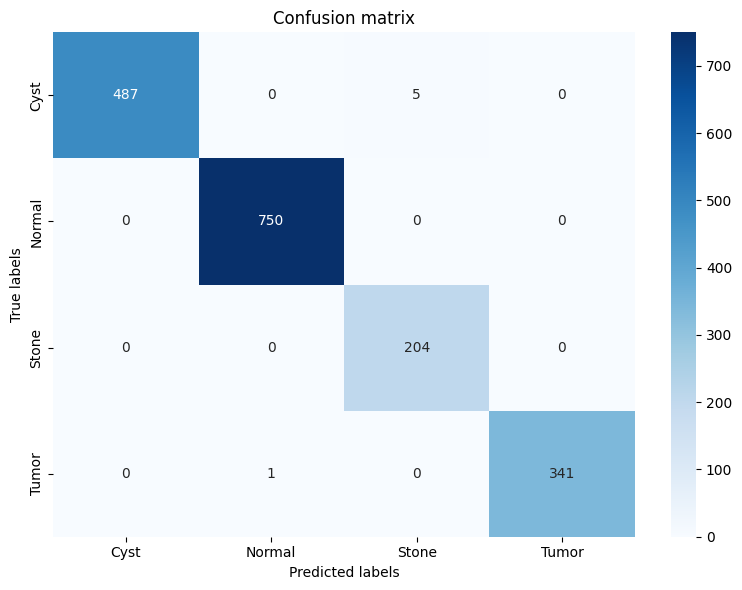


Classification Report:
              precision    recall  f1-score   support

        Cyst       1.00      0.99      0.99       492
      Normal       1.00      1.00      1.00       750
       Stone       0.98      1.00      0.99       204
       Tumor       1.00      1.00      1.00       342

    accuracy                           1.00      1788
   macro avg       0.99      1.00      1.00      1788
weighted avg       1.00      1.00      1.00      1788

Accuracy for 'Cyst': 0.9898
Accuracy for 'Normal': 1.0000
Accuracy for 'Stone': 1.0000
Accuracy for 'Tumor': 0.9971

Overall Accuracy : 99.66%
Precision        : 99.37%
Recall           : 99.67%
F1-Score         : 99.52%


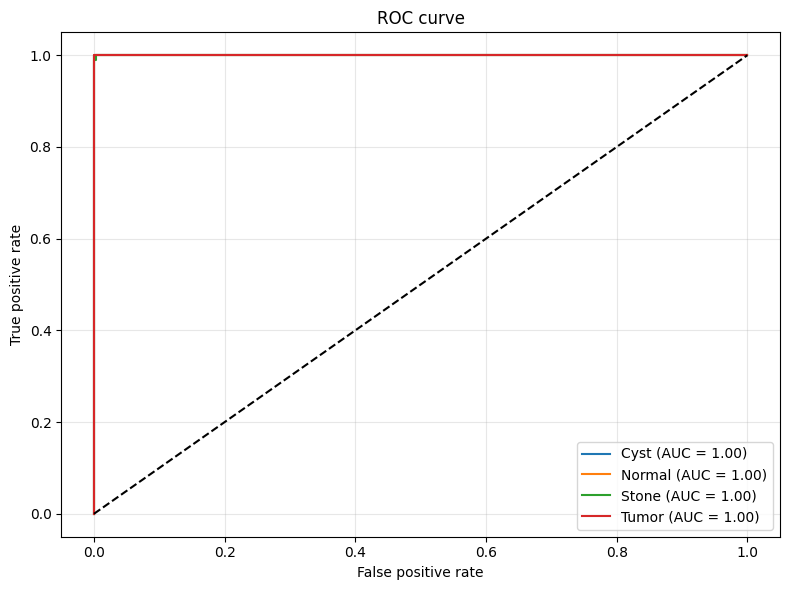


FINAL TEST SET EVALUATION
38/38 [==============================] - 3s 64ms/step - loss: 0.0318 - accuracy: 0.9908

Test Loss:     0.0318
Test Accuracy: 0.9908 (99.08%)


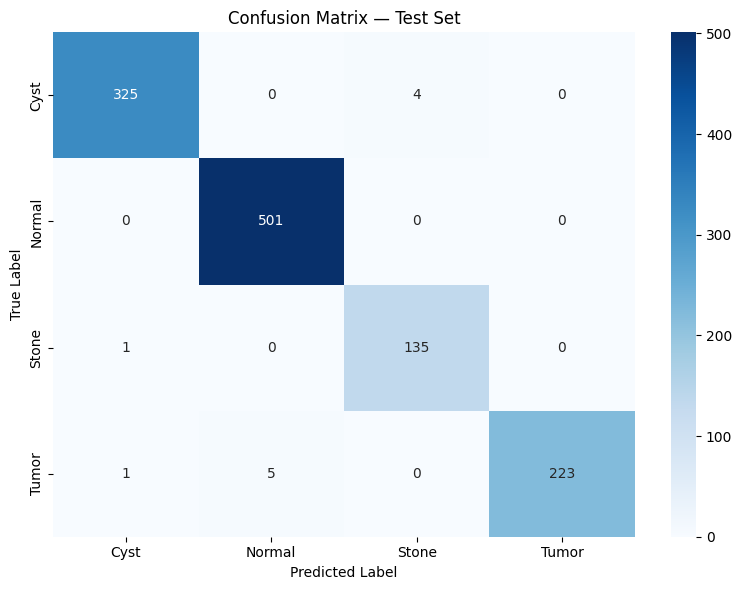


Classification Report:
              precision    recall  f1-score   support

        Cyst       0.99      0.99      0.99       329
      Normal       0.99      1.00      1.00       501
       Stone       0.97      0.99      0.98       136
       Tumor       1.00      0.97      0.99       229

    accuracy                           0.99      1195
   macro avg       0.99      0.99      0.99      1195
weighted avg       0.99      0.99      0.99      1195



In [4]:
#   Accuracy curve  
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"],     label="Train accuracy")
plt.plot(history.history["val_accuracy"], label="Val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#   Collect predictions 
start_test_time = time.time()

y_true, y_pred_prob = [], []
for images, labels in val_data:                         
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred_prob.extend(preds)

y_true         = np.array(y_true)
y_pred_prob    = np.array(y_pred_prob)
y_pred_classes = np.argmax(y_pred_prob, axis=1)

testing_time = time.time() - start_test_time
print(f"Inference time: {testing_time:.2f}s")

#   Confusion matrix  
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.title("Confusion matrix")
plt.tight_layout()
plt.show()

# ── Classification report ──────────────────────────────────────────────
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

# ── Per-class accuracy ─────────────────────────────────────────────────
class_accuracy = cm.diagonal() / cm.sum(axis=1)
for i, name in enumerate(class_names):
    print(f"Accuracy for '{name}': {class_accuracy[i]:.4f}")

# ── Overall metrics ────────────────────────────────────────────────────
accuracy  = np.sum(y_pred_classes == y_true) / len(y_true)
precision = precision_score(y_true, y_pred_classes, average="macro")
recall    = recall_score(y_true, y_pred_classes, average="macro")
f1        = f1_score(y_true, y_pred_classes, average="macro")

print(f"\nOverall Accuracy : {accuracy*100:.2f}%")
print(f"Precision        : {precision*100:.2f}%")
print(f"Recall           : {recall*100:.2f}%")
print(f"F1-Score         : {f1*100:.2f}%")

# ── ROC curve ──────────────────────────────────────────────────────────
y_true_onehot = to_categorical(y_true, num_classes=NUM_CLASSES)
plt.figure(figsize=(8, 6))
for i, name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_true_onehot[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], "k--")
plt.title("ROC curve")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


print("\n" + "="*50)
print("FINAL TEST SET EVALUATION")
print("="*50)
test_loss, test_accuracy = model.evaluate(test_data, verbose=1)
print(f"\nTest Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# ── Confusion Matrix on Test Set ──────────────────────────────────────────────
y_true, y_pred = [], []

for images, labels in test_data:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Confusion Matrix — Test Set")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))